<a href="https://colab.research.google.com/github/prathyusha-mallela/just-for-fun-analysis/blob/main/visual_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Decisions ===
  P1 | Angry My Way Highway Sherlyn Chopra Fan  | Total=10 (medium) | REJECT  | NORMAL_MISMATCH | NonNegMismatch=True
     Unknown non-negs: is_virgin, smoked, drinks/drugs, wants_kids, atheist
  P2 | Nonchalant Smoker                        | Total= 6 (low) | REJECT  | NORMAL_MISMATCH | NonNegMismatch=True
     Unknown non-negs: drinks/drugs, wants_kids, atheist
  P6 | Ghosting Performing-Empathy Catfisher    | Total=34 (extreme) | BLOCK   | UNSAFE          | NonNegMismatch=True
     Unknown non-negs: smoked, drinks/drugs, wants_kids, atheist
  d9 | Stalking Plant Scientist                 | Total=20 (high) | BLOCK   | UNSAFE          | NonNegMismatch=True
     Unknown non-negs: is_virgin, smoked, drinks/drugs, wants_kids, atheist, vegetarian, brahmin, south_indian
 d15 | Mocking Projector All Women Are Bad Guy  | Total=12 (medium) | BLOCK   | UNSAFE          | NonNegMismatch=True
     Unknown non-negs: is_virgin, smoked, drinks/drugs, wants_kids, atheist, vegetaria

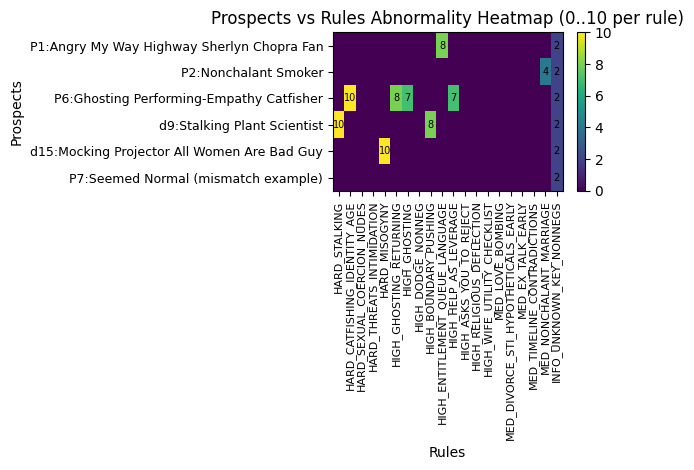

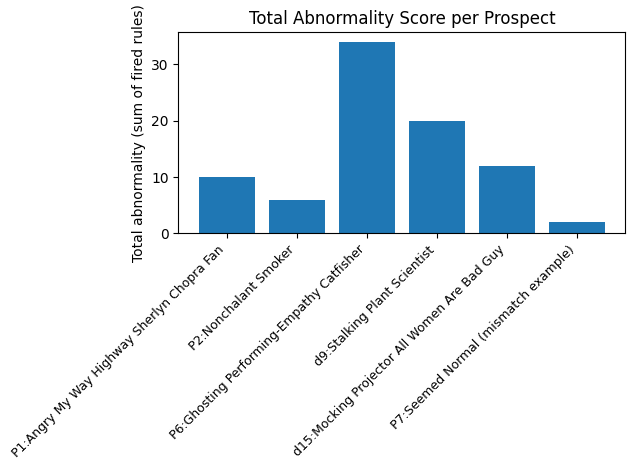

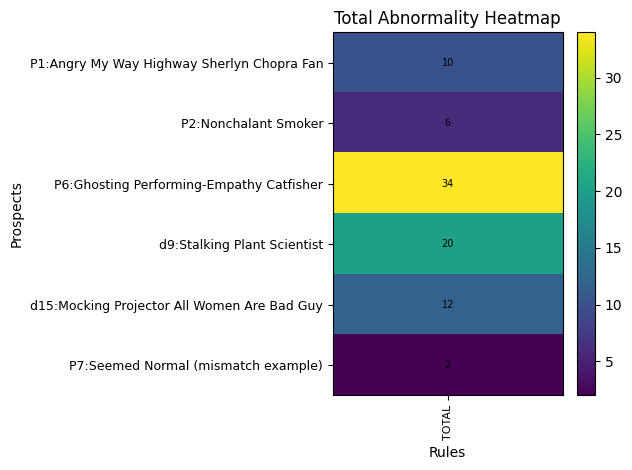

In [1]:
"""
Weed-out Rule Engine + Heatmap (Matplotlib only, no seaborn)

What you get:
- A rule engine where each fired rule contributes an abnormality score (1..10)
- Per-prospect per-rule abnormality matrix
- A heatmap to visually compare prospects across rules
- A second heatmap showing only the TOTAL abnormality score (1 column)
- Printed decisions: BLOCK / REJECT / CAUTION / PASS + category

How to use:
1) Put your prospects into the PROSPECTS list (behaviors, phrases, facts).
2) Run this file.
"""

from __future__ import annotations
from dataclasses import dataclass, field
from typing import Callable, List, Optional, Set, Dict, Tuple
import re
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1) Your Non-Negotiables (edit here)
# ============================================================

@dataclass
class NonNegotiables:
    # Core values
    partner_must_be_virgin: bool = True
    no_smoking: bool = True
    no_addictions: bool = True  # alcohol/drugs
    wants_kids_required: bool = True
    not_atheist: bool = True

    # Culture/food
    must_be_vegetarian: bool = True
    must_be_brahmin: bool = True
    must_be_south_indian: bool = True

    # Safety hard lines
    zero_tolerance_stalking: bool = True
    zero_tolerance_catfishing: bool = True
    zero_tolerance_sexual_coercion: bool = True
    zero_tolerance_misogyny: bool = True

    # Optional constraint
    max_age_diff_years: Optional[int] = 2


# ============================================================
# 2) Data model for each match
# ============================================================

@dataclass
class Prospect:
    id: str
    alias: str = ""

    key_phrases: List[str] = field(default_factory=list)
    notes: str = ""
    behaviors: Set[str] = field(default_factory=set)

    # Facts/claims (True/False/None)
    is_virgin: Optional[bool] = None
    smoked: Optional[bool] = None
    drinks: Optional[bool] = None
    drugs: Optional[bool] = None
    wants_kids: Optional[bool] = None
    atheist: Optional[bool] = None
    age_diff_years: Optional[int] = None

    vegetarian: Optional[bool] = None
    brahmin: Optional[bool] = None
    south_indian: Optional[bool] = None

    attraction: Optional[str] = None


# ============================================================
# 3) Rule engine structures
# ============================================================

@dataclass
class Rule:
    rule_id: str
    severity: str             # HARD_EXIT | HIGH | MEDIUM | LOW | INFO
    abnormality: int          # 1..10 (if fired)
    tags: List[str]
    condition: Callable[[Prospect, NonNegotiables], bool]
    reason: str


def clamp_1_10(x: int) -> int:
    return max(1, min(10, x))


def has_behavior(p: Prospect, *tokens: str) -> bool:
    lower = {b.lower() for b in p.behaviors}
    return any(t.lower() in lower for t in tokens)


def phrase_matches(p: Prospect, patterns: List[str]) -> bool:
    text = " | ".join(p.key_phrases + [p.notes]).lower()
    return any(re.search(ptn, text) for ptn in patterns)


# ============================================================
# 4) Build rules (each rule returns 1..10 abnormality when fired)
# ============================================================

def build_rules() -> List[Rule]:
    rules: List[Rule] = []

    # ---------------- HARD EXIT (UNSAFE) ----------------
    rules.append(Rule(
        rule_id="HARD_STALKING",
        severity="HARD_EXIT",
        abnormality=10,
        tags=["safety", "stalking"],
        condition=lambda p, nn: nn.zero_tolerance_stalking and has_behavior(p, "stalking", "doxxing"),
        reason="Stalking/doxxing is an immediate safety exit."
    ))

    rules.append(Rule(
        rule_id="HARD_CATFISHING_IDENTITY_AGE",
        severity="HARD_EXIT",
        abnormality=10,
        tags=["safety", "deception", "catfishing"],
        condition=lambda p, nn: nn.zero_tolerance_catfishing and has_behavior(p, "catfishing", "identity_mismatch", "age_manipulation"),
        reason="Identity/age manipulation/catfishing is an immediate safety exit."
    ))

    rules.append(Rule(
        rule_id="HARD_SEXUAL_COERCION_NUDES",
        severity="HARD_EXIT",
        abnormality=10,
        tags=["safety", "sexual-pressure"],
        condition=lambda p, nn: nn.zero_tolerance_sexual_coercion and has_behavior(p, "asked_for_nudes", "sexual_pressure", "explicit_sex_talk"),
        reason="Nudes request / coercion / explicit sex talk early is an immediate exit."
    ))

    rules.append(Rule(
        rule_id="HARD_THREATS_INTIMIDATION",
        severity="HARD_EXIT",
        abnormality=10,
        tags=["safety", "threats"],
        condition=lambda p, nn: has_behavior(p, "threatening", "intimidation"),
        reason="Threats/intimidation is an immediate exit."
    ))

    rules.append(Rule(
        rule_id="HARD_MISOGYNY",
        severity="HARD_EXIT",
        abnormality=10,
        tags=["safety", "misogyny"],
        condition=lambda p, nn: nn.zero_tolerance_misogyny and (
            has_behavior(p, "misogyny") or phrase_matches(p, [r"all women are bad", r"women are evil"])
        ),
        reason="Misogyny/contempt toward women is unsafe and an immediate exit."
    ))

    # ---------------- HIGH RISK (NOT NORMAL) ----------------
    rules.append(Rule(
        rule_id="HIGH_GHOSTING_RETURNING",
        severity="HIGH",
        abnormality=8,
        tags=["inconsistency", "reliability"],
        condition=lambda p, nn: has_behavior(p, "ghosting") and has_behavior(p, "returned_after_ghosting"),
        reason="Ghosting + returning suggests hot-cold cycles and unreliability."
    ))

    rules.append(Rule(
        rule_id="HIGH_GHOSTING",
        severity="HIGH",
        abnormality=7,
        tags=["inconsistency", "reliability"],
        condition=lambda p, nn: has_behavior(p, "ghosting"),
        reason="Ghosting indicates poor communication and low reliability."
    ))

    rules.append(Rule(
        rule_id="HIGH_DODGE_NONNEG",
        severity="HIGH",
        abnormality=8,
        tags=["integrity", "nonneg-evasion"],
        condition=lambda p, nn: has_behavior(p, "dodged_nonneg") or phrase_matches(p, [r"\bdeflect", r"\bavoid", r"went silent", r"changed the topic"]),
        reason="Dodging non-negotiable questions is a strong integrity risk."
    ))

    rules.append(Rule(
        rule_id="HIGH_BOUNDARY_PUSHING",
        severity="HIGH",
        abnormality=8,
        tags=["boundary-violation", "control"],
        condition=lambda p, nn: has_behavior(p, "boundary_pushing", "no_not_respected"),
        reason="Boundary pushing / 'no' not respected is strong abnormality."
    ))

    rules.append(Rule(
        rule_id="HIGH_ENTITLEMENT_QUEUE_LANGUAGE",
        severity="HIGH",
        abnormality=8,
        tags=["entitlement", "objectification"],
        condition=lambda p, nn: phrase_matches(p, [r"queue", r"line of girls", r"waiting for women"]),
        reason="Entitlement/objectification language about women is a strong character red flag."
    ))

    rules.append(Rule(
        rule_id="HIGH_HELP_AS_LEVERAGE",
        severity="HIGH",
        abnormality=7,
        tags=["control", "power-dynamic"],
        condition=lambda p, nn: has_behavior(p, "help_as_leverage") or phrase_matches(p, [r"helping because you('re| are) a girl", r"you need help"]),
        reason="Help framed as gender/power can become leverage/control."
    ))

    rules.append(Rule(
        rule_id="HIGH_ASKS_YOU_TO_REJECT",
        severity="HIGH",
        abnormality=7,
        tags=["avoidance", "cowardice"],
        condition=lambda p, nn: phrase_matches(p, [r"can you reject me"]),
        reason="Asking you to reject him so he avoids accountability indicates low maturity."
    ))

    rules.append(Rule(
        rule_id="HIGH_RELIGIOUS_DEFLECTION",
        severity="HIGH",
        abnormality=6,
        tags=["performance", "integrity"],
        condition=lambda p, nn: has_behavior(p, "religious_deflection") or phrase_matches(p, [r"pravachan", r"family values", r"\breligio"]),
        reason="Over-preaching/pravachan during hard questions can signal deflection/performance."
    ))

    rules.append(Rule(
        rule_id="HIGH_WIFE_UTILITY_CHECKLIST",
        severity="HIGH",
        abnormality=6,
        tags=["utility-view", "control"],
        condition=lambda p, nn: has_behavior(p, "wife_checklist") or phrase_matches(p, [r"skills (a )?woman should have", r"driving", r"finances.*important"]),
        reason="Treating spouse as utility checklist (skills/finances) is a control/transaction red flag."
    ))

    # ---------------- MEDIUM RISK ----------------
    rules.append(Rule(
        rule_id="MED_LOVE_BOMBING",
        severity="MEDIUM",
        abnormality=5,
        tags=["watch", "soft-risk"],
        condition=lambda p, nn: has_behavior(p, "love_bombing", "compliment_bombing"),
        reason="Love/compliment bombing early can be manipulation. Watch for boundary tests."
    ))

    rules.append(Rule(
        rule_id="MED_DIVORCE_STI_HYPOTHETICALS_EARLY",
        severity="MEDIUM",
        abnormality=5,
        tags=["watch", "soft-risk"],
        condition=lambda p, nn: phrase_matches(p, [r"divorce", r"case scenarios", r"std", r"sti"]),
        reason="Obsessive divorce/STD hypotheticals early can signal insecurity/control framing."
    ))

    rules.append(Rule(
        rule_id="MED_EX_TALK_EARLY",
        severity="MEDIUM",
        abnormality=4,
        tags=["watch", "soft-risk"],
        condition=lambda p, nn: phrase_matches(p, [r"\bmy ex\b", r"she('d| would) be my wife"]),
        reason="Ex-centric talk early is a watch-item for unresolved attachment."
    ))

    rules.append(Rule(
        rule_id="MED_TIMELINE_CONTRADICTIONS",
        severity="MEDIUM",
        abnormality=5,
        tags=["inconsistency", "integrity"],
        condition=lambda p, nn: has_behavior(p, "contradictory_story", "timeline_inconsistent"),
        reason="Contradictions/inconsistent story indicate unreliability or deception."
    ))

    rules.append(Rule(
        rule_id="MED_NONCHALANT_MARRIAGE",
        severity="MEDIUM",
        abnormality=4,
        tags=["low-intent", "immaturity"],
        condition=lambda p, nn: has_behavior(p, "nonchalant_about_marriage") or phrase_matches(p, [r"you('ll| will) get used to it", r"been through many of this"]),
        reason="Dismissive/nonchalant attitude toward marriage suggests low intent or immaturity."
    ))

    # ---------------- INFO (verification) ----------------
    rules.append(Rule(
        rule_id="INFO_UNKNOWN_KEY_NONNEGS",
        severity="INFO",
        abnormality=2,
        tags=["verify-nonneg", "watch"],
        condition=lambda p, nn: (
            (nn.partner_must_be_virgin and p.is_virgin is None) or
            (nn.no_smoking and p.smoked is None) or
            (nn.no_addictions and (p.drinks is None and p.drugs is None)) or
            (nn.must_be_vegetarian and p.vegetarian is None) or
            (nn.must_be_brahmin and p.brahmin is None) or
            (nn.must_be_south_indian and p.south_indian is None)
        ),
        reason="Missing info on key non-negotiables—verify early (not a red flag by itself)."
    ))

    return rules


# ============================================================
# 5) Non-neg mismatch + unknown non-negs
# ============================================================

def nonneg_mismatch(p: Prospect, nn: NonNegotiables) -> bool:
    if nn.partner_must_be_virgin and p.is_virgin is False:
        return True
    if nn.no_smoking and p.smoked is True:
        return True
    if nn.no_addictions and (p.drinks is True or p.drugs is True):
        return True
    if nn.wants_kids_required and p.wants_kids is False:
        return True
    if nn.not_atheist and p.atheist is True:
        return True

    if nn.must_be_vegetarian and p.vegetarian is False:
        return True
    if nn.must_be_brahmin and p.brahmin is False:
        return True
    if nn.must_be_south_indian and p.south_indian is False:
        return True

    if nn.max_age_diff_years is not None and p.age_diff_years is not None:
        if abs(p.age_diff_years) > nn.max_age_diff_years:
            return True

    return False


def unknown_nonneg_fields(p: Prospect, nn: NonNegotiables) -> List[str]:
    unknowns: List[str] = []
    if nn.partner_must_be_virgin and p.is_virgin is None:
        unknowns.append("is_virgin")
    if nn.no_smoking and p.smoked is None:
        unknowns.append("smoked")
    if nn.no_addictions and (p.drinks is None and p.drugs is None):
        unknowns.append("drinks/drugs")
    if nn.wants_kids_required and p.wants_kids is None:
        unknowns.append("wants_kids")
    if nn.not_atheist and p.atheist is None:
        unknowns.append("atheist")
    if nn.must_be_vegetarian and p.vegetarian is None:
        unknowns.append("vegetarian")
    if nn.must_be_brahmin and p.brahmin is None:
        unknowns.append("brahmin")
    if nn.must_be_south_indian and p.south_indian is None:
        unknowns.append("south_indian")
    return unknowns


# ============================================================
# 6) Evaluate one prospect -> per-rule scores + decision
# ============================================================

def evaluate_prospect(
    p: Prospect,
    nn: NonNegotiables,
    rules: List[Rule],
    not_normal_threshold: int = 18,
    unsafe_threshold: int = 26
) -> Tuple[Dict[str, int], Dict[str, str | int | bool | List[str]]]:
    """
    Returns:
      per_rule_scores: {rule_id: abnormality(0..10)}
      summary: dict with decision fields
    """
    per_rule: Dict[str, int] = {}
    tags: Set[str] = set()
    hard_exit = False
    total = 0

    for r in rules:
        fired = r.condition(p, nn)
        score = clamp_1_10(r.abnormality) if fired else 0
        per_rule[r.rule_id] = score
        if fired:
            total += score
            tags.update(r.tags)
            if r.severity == "HARD_EXIT":
                hard_exit = True

    mismatch = nonneg_mismatch(p, nn)
    unknowns = unknown_nonneg_fields(p, nn)

    # Decision logic
    if hard_exit:
        category = "UNSAFE"
        decision = "BLOCK"
    elif total >= unsafe_threshold:
        category = "UNSAFE"
        decision = "BLOCK"
    elif total >= not_normal_threshold:
        category = "NOT_NORMAL"
        decision = "REJECT"
    else:
        if mismatch:
            category = "NORMAL_MISMATCH"
            decision = "REJECT"
        else:
            category = "NORMAL_POSSIBLE"
            decision = "PASS"

    if decision == "PASS" and (unknowns or ("watch" in tags) or ("soft-risk" in tags) or ("inconsistency" in tags)):
        decision = "CAUTION"

    level = "low"
    if total >= 30:
        level = "extreme"
    elif total >= 20:
        level = "high"
    elif total >= 10:
        level = "medium"

    summary = {
        "id": p.id,
        "alias": p.alias,
        "abnormality_total": total,
        "abnormality_level": level,
        "category": category,
        "decision": decision,
        "nonneg_mismatch": mismatch,
        "unknown_nonneg_fields": unknowns,
        "tags": sorted(tags),
    }
    return per_rule, summary


# ============================================================
# 7) YOUR PROSPECTS (edit/extend this list)
# ============================================================

PROSPECTS: List[Prospect] = [
    Prospect(
        id="P1",
        alias="Angry My Way Highway Sherlyn Chopra Fan",
        key_phrases=["waiting for women in a queue", "I have a lot of kopam"],
        behaviors={"entitlement", "anger"},
        notes="Irritated, ego-driven vibe.",
        age_diff_years=3,
        vegetarian=True, brahmin=True, south_indian=True
    ),
    Prospect(
        id="P2",
        alias="Nonchalant Smoker",
        key_phrases=["Have been through many of this, you’ll get used to it"],
        behaviors={"nonchalant_about_marriage"},
        smoked=True,
        is_virgin=False,
        vegetarian=False, brahmin=True, south_indian=True,
        age_diff_years=3
    ),
    Prospect(
        id="P6",
        alias="Ghosting Performing-Empathy Catfisher",
        key_phrases=[
            "let’s see where this goes if it has to happen it will",
            "I’m not telling anything to my kids about what I did",
            "alcohol? Of course Bangalore",
        ],
        behaviors={"ghosting", "returned_after_ghosting", "catfishing", "age_manipulation", "help_as_leverage"},
        notes="Changed age, targeted 18–33 bracket.",
        is_virgin=False,
        vegetarian=True, brahmin=True, south_indian=True,
        age_diff_years=5
    ),
    Prospect(
        id="d9",
        alias="Stalking Plant Scientist",
        behaviors={"stalking", "boundary_pushing"},
        notes="Repeated unwanted views and forced connection; safety fear.",
        age_diff_years=4
    ),
    Prospect(
        id="d15",
        alias="Mocking Projector All Women Are Bad Guy",
        behaviors={"misogyny"},
        key_phrases=["all women are bad", "women are evil"],
        notes="Mocked values; projected hatred.",
        age_diff_years=4
    ),
    Prospect(
        id="P7",
        alias="Seemed Normal (mismatch example)",
        key_phrases=[
            "this is not a random conversation",
            "I propose we take time and decide if we both want to talk again",
            "growth mentality is something I’m looking for"
        ],
        behaviors={"direct", "reflective", "respected_no"},
        is_virgin=False,  # mismatch for your non-neg
        smoked=False,
        atheist=False,
        wants_kids=True,
        vegetarian=True, brahmin=True, south_indian=True,
        age_diff_years=0
    ),
]


# ============================================================
# 8) Heatmap plotting (Matplotlib only)
# ============================================================

def plot_heatmap(matrix: np.ndarray, row_labels: List[str], col_labels: List[str], title: str) -> None:
    """
    matrix: shape (n_rows, n_cols), values typically 0..10
    """
    fig, ax = plt.subplots()
    im = ax.imshow(matrix, aspect="auto")  # default colormap, no manual colors

    ax.set_title(title)
    ax.set_xlabel("Rules")
    ax.set_ylabel("Prospects")

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(row_labels, fontsize=9)

    # annotate each cell with number (optional; can be noisy for many prospects)
    if matrix.size <= 1200:  # avoid clutter for huge matrices
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                val = matrix[i, j]
                if val != 0:
                    ax.text(j, i, str(int(val)), ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()


def plot_total_bar(totals: List[int], labels: List[str], title: str) -> None:
    fig, ax = plt.subplots()
    x = np.arange(len(labels))
    ax.bar(x, totals)
    ax.set_title(title)
    ax.set_ylabel("Total abnormality (sum of fired rules)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    fig.tight_layout()
    plt.show()


# ============================================================
# 9) Main: run evaluation + build matrix + plot
# ============================================================

def main():
    nn = NonNegotiables(
        partner_must_be_virgin=True,
        no_smoking=True,
        no_addictions=True,
        wants_kids_required=True,
        not_atheist=True,
        must_be_vegetarian=True,
        must_be_brahmin=True,
        must_be_south_indian=True,
        zero_tolerance_stalking=True,
        zero_tolerance_catfishing=True,
        zero_tolerance_sexual_coercion=True,
        zero_tolerance_misogyny=True,
        max_age_diff_years=2
    )

    rules = build_rules()
    rule_ids = [r.rule_id for r in rules]

    per_rule_rows: List[List[int]] = []
    row_labels: List[str] = []
    summaries: List[Dict] = []
    totals: List[int] = []

    for p in PROSPECTS:
        per_rule, summary = evaluate_prospect(p, nn, rules)
        row = [per_rule[rid] for rid in rule_ids]
        per_rule_rows.append(row)

        label = f"{p.id}:{p.alias}"
        row_labels.append(label)

        summaries.append(summary)
        totals.append(int(summary["abnormality_total"]))

    matrix = np.array(per_rule_rows, dtype=int)

    # Print summary table (text)
    print("\n=== Decisions ===")
    for s in summaries:
        print(
            f"{s['id']:>4} | {s['alias'][:40]:40s} | "
            f"Total={s['abnormality_total']:>2} ({s['abnormality_level']}) | "
            f"{s['decision']:<7} | {s['category']:<15} | "
            f"NonNegMismatch={str(s['nonneg_mismatch'])}"
        )
        if s["unknown_nonneg_fields"]:
            print(f"     Unknown non-negs: {', '.join(s['unknown_nonneg_fields'])}")

    # Heatmap: prospects x rules
    plot_heatmap(
        matrix=matrix,
        row_labels=row_labels,
        col_labels=rule_ids,
        title="Prospects vs Rules Abnormality Heatmap (0..10 per rule)"
    )

    # Total abnormality bar chart
    plot_total_bar(
        totals=totals,
        labels=row_labels,
        title="Total Abnormality Score per Prospect"
    )

    # Optional: a 1-column heatmap for totals (nice if many prospects)
    total_matrix = np.array(totals, dtype=int).reshape(-1, 1)
    plot_heatmap(
        matrix=total_matrix,
        row_labels=row_labels,
        col_labels=["TOTAL"],
        title="Total Abnormality Heatmap"
    )


if __name__ == "__main__":
    main()
